In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv('jshare.csv')
data.head()

,date,data
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-02,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61


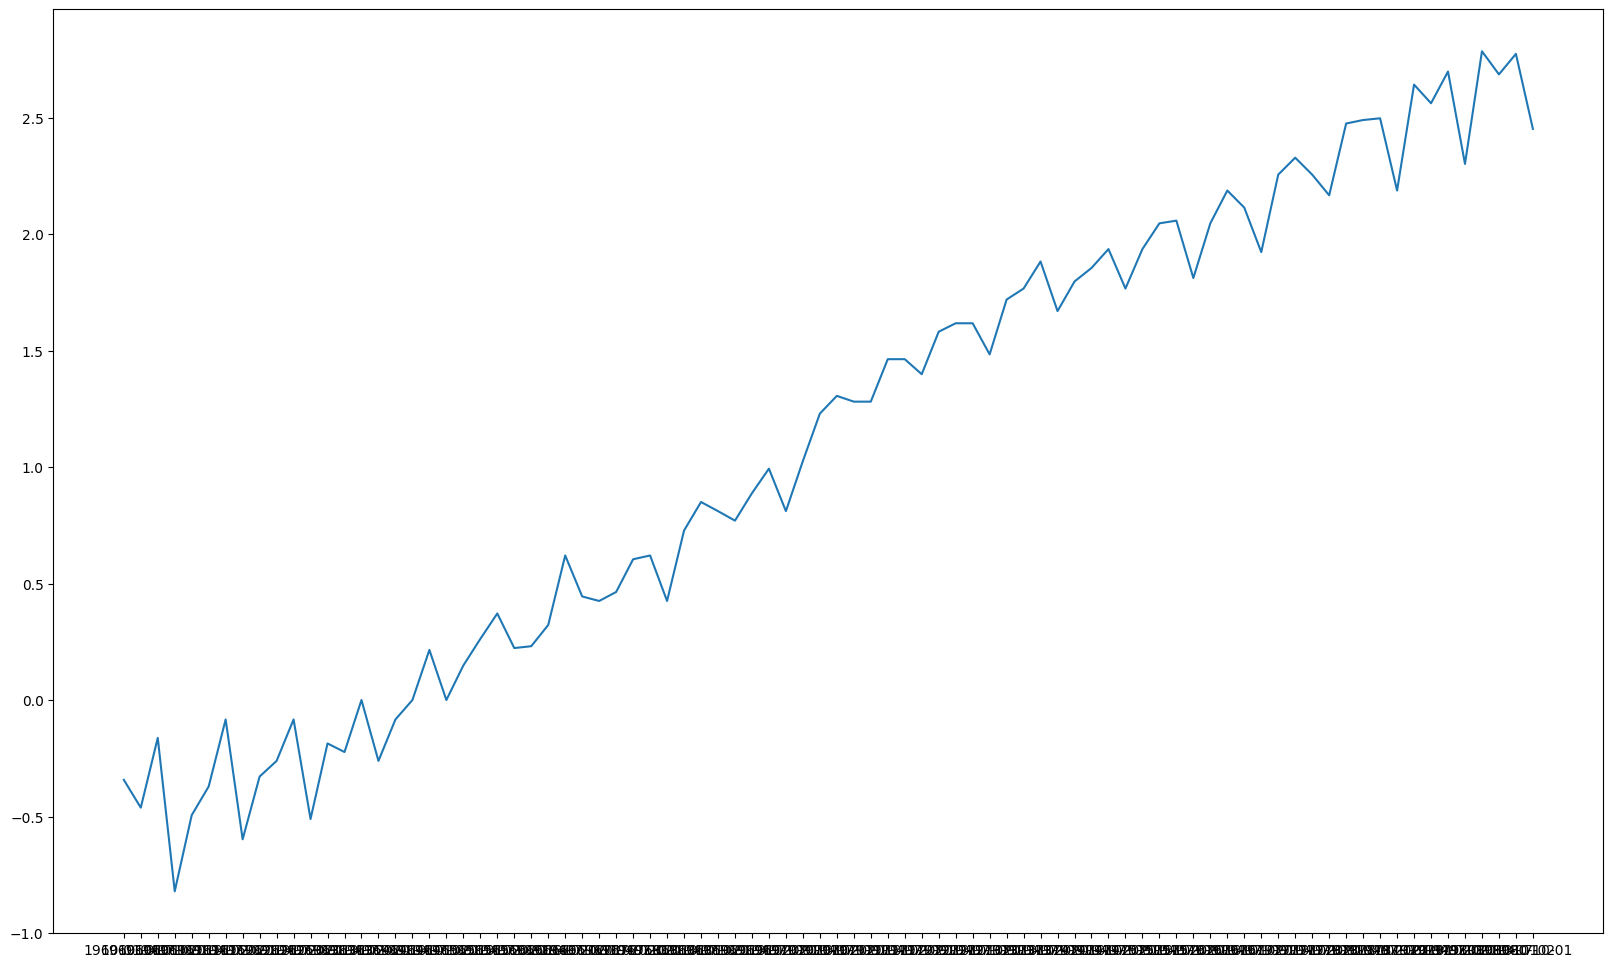

In [11]:
plt.figure(figsize=(20, 12))
plt.plot(data['date'], data['data'])
plt.show()

In [5]:
from statsmodels.tsa.stattools import adfuller

In [6]:
adfuller(data['data'])

(np.float64(2.7420165734574704),
 1.0,
 11,
 72,
 {'1%': np.float64(-3.524624466842421),
  '5%': np.float64(-2.9026070739026064),
  '10%': np.float64(-2.5886785262345677)},
 np.float64(82.63760283301102))

In [7]:
data['data'] = np.log(data['data'])

In [8]:
adfuller(data['data'])

(np.float64(-0.8040574622338382),
 np.float64(0.8179273123168607),
 4,
 79,
 {'1%': np.float64(-3.5159766913976376),
  '5%': np.float64(-2.898885703483903),
  '10%': np.float64(-2.5866935058484217)},
 np.float64(-142.1892728398871))

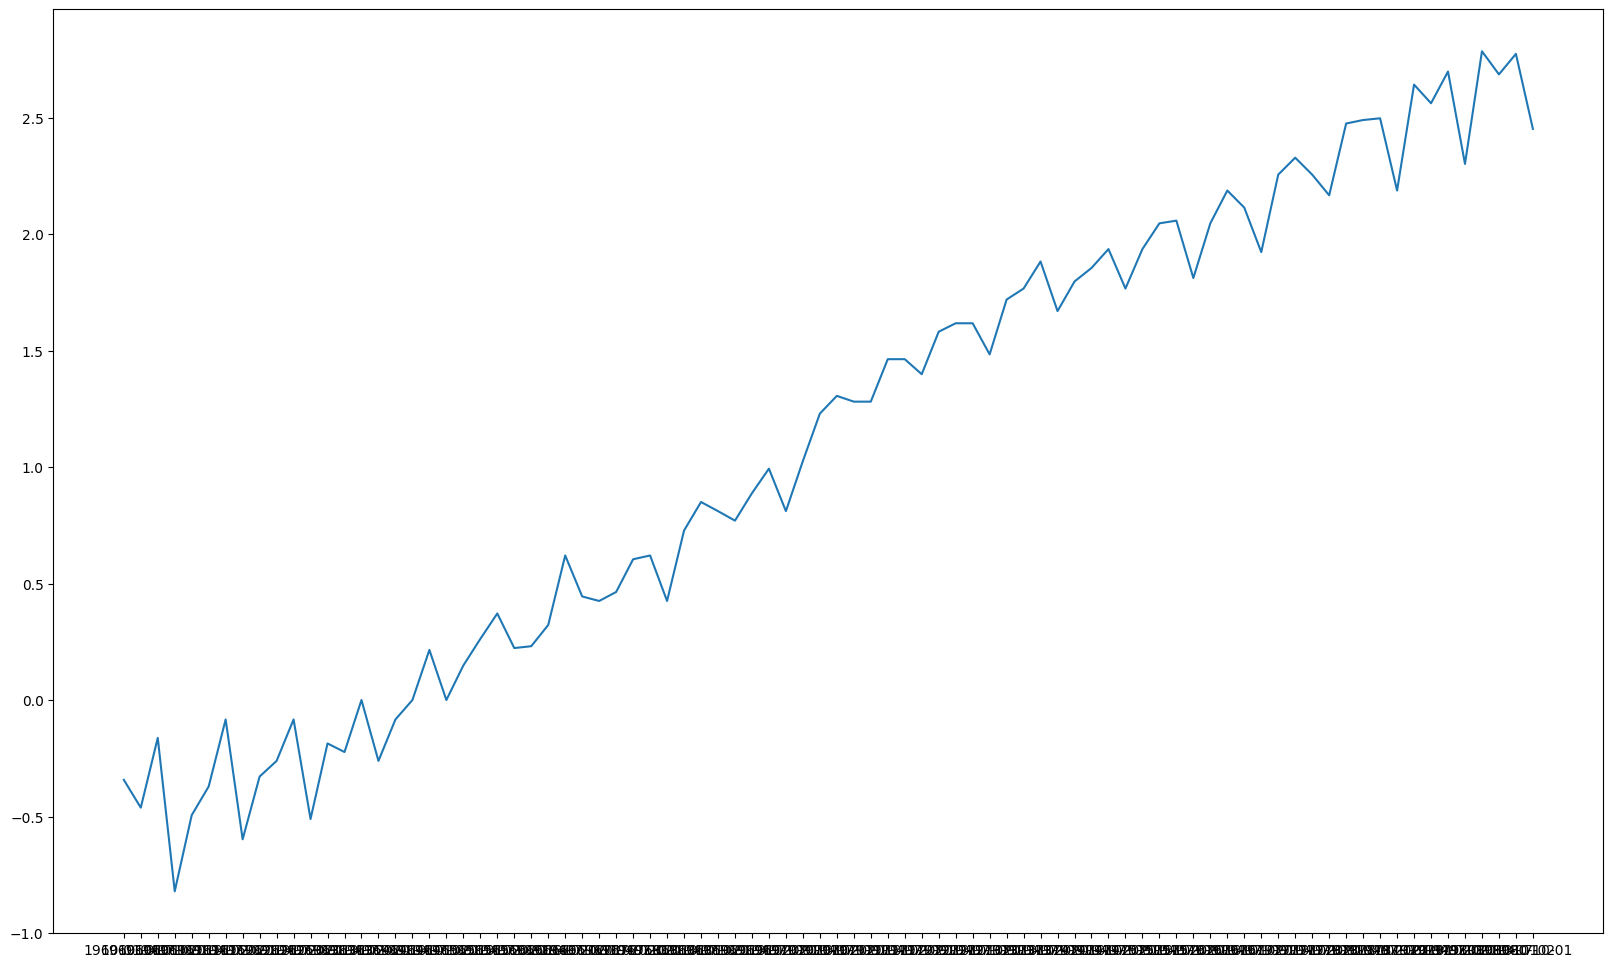

In [10]:
plt.figure(figsize=(20, 12))
plt.plot(data['date'], data['data'])
plt.show()

In [12]:
sample = pd.Series([1, 1, 2, 3, 5, 8, 13, 21, 32, 55])
sample.diff(4)

0     NaN
1     NaN
2     NaN
3     NaN
4     4.0
5     7.0
6    11.0
7    18.0
8    27.0
9    47.0
dtype: float64

In [13]:
data['data'] = data['data'].diff(1)

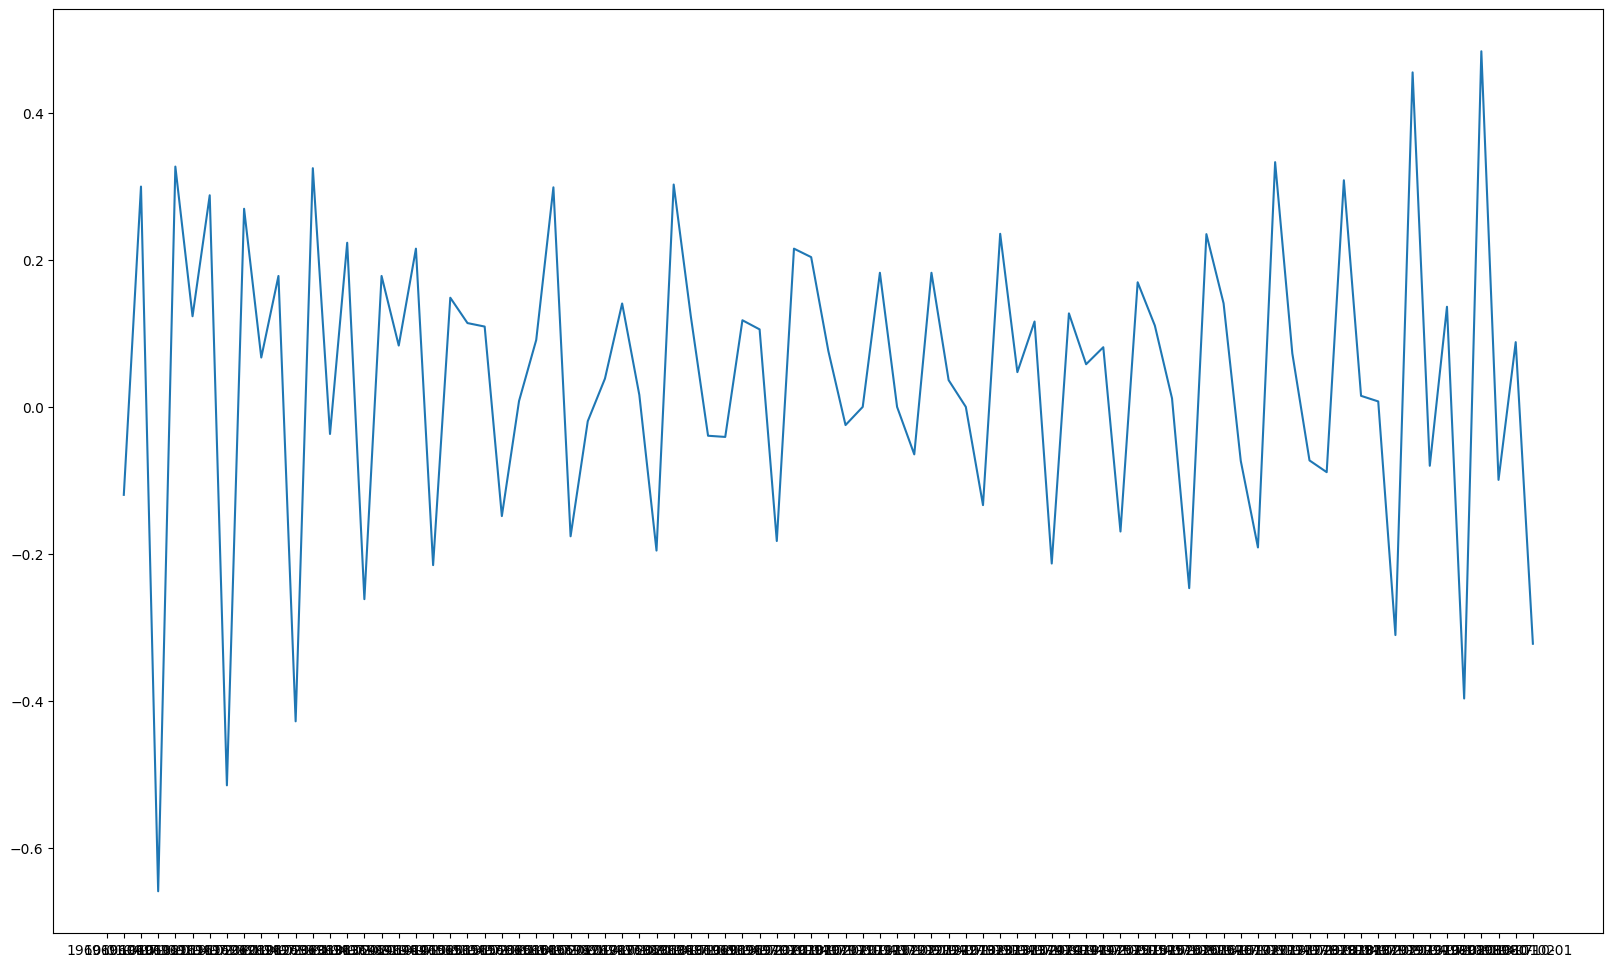

In [15]:
plt.figure(figsize=(20, 12))
plt.plot(data['date'], data['data'])
plt.show()

In [16]:
data = data.drop(data.index[0])
adfuller(data['data'])

(np.float64(-4.3170439458118315),
 np.float64(0.00041497314044407544),
 5,
 77,
 {'1%': np.float64(-3.518281134660583),
  '5%': np.float64(-2.899878185191432),
  '10%': np.float64(-2.5872229937594873)},
 np.float64(-140.7202208245293))

In [17]:
data['data'] = data['data'].diff(4)

In [18]:
data

,date,data
1,1960-04-01,NaN
2,1960-07-02,NaN
3,1960-10-01,NaN
4,1961-01-01,NaN
5,1961-04-02,0.242778
...,...,...
79,1979-10-01,-0.086260
80,1980-01-01,0.028690
81,1980-04-01,-0.019164
82,1980-07-02,-0.048099


In [19]:
data = data.drop([1, 2, 3, 4], axis=0)
adfuller(data['data'])

(np.float64(-6.63080510991427),
 np.float64(5.72157869513596e-09),
 5,
 73,
 {'1%': np.float64(-3.5232835753964475),
  '5%': np.float64(-2.902030597326081),
  '10%': np.float64(-2.5883710883843123)},
 np.float64(-130.60404810222016))

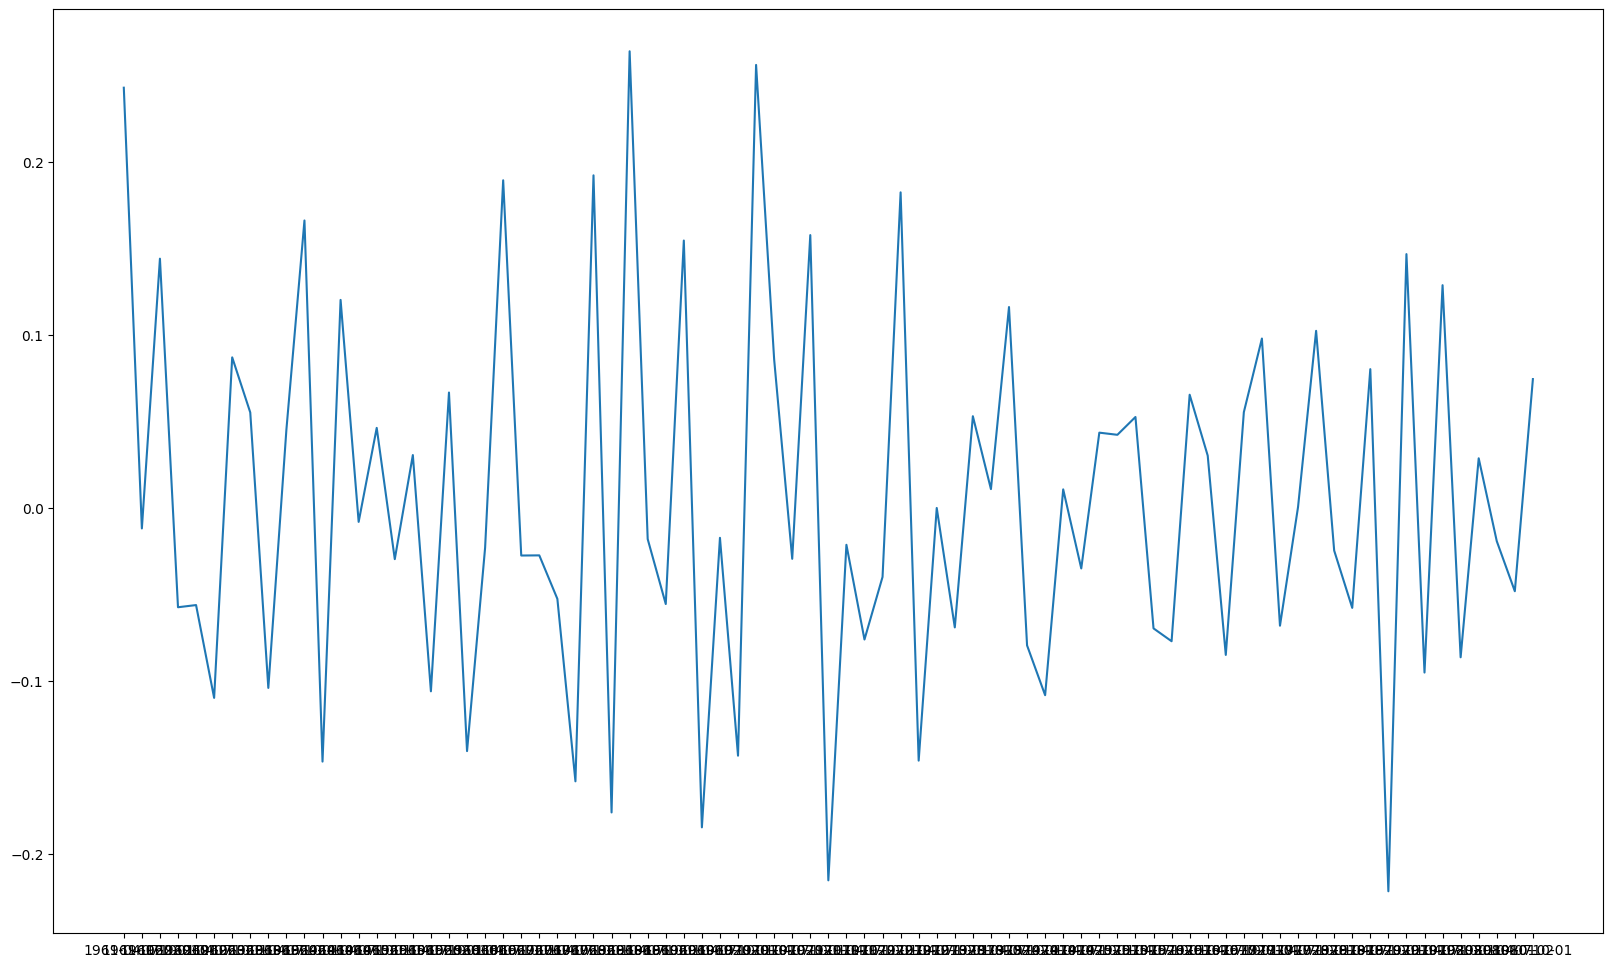

In [20]:
plt.figure(figsize=(20, 12))
plt.plot(data['date'], data['data'])
plt.show()

In [21]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [22]:
data2 = pd.read_csv('jshare.csv')
data2.head()

,date,data
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-02,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61


In [24]:
model = SARIMAX(data2['data'], order=(3, 1, 3), seasonal_order=(2, 1, 2, 4))

In [25]:
res = model.fit()

c:\Users\amir\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [26]:
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                       SARIMAX Results                                        
==============================================================================================
Dep. Variable:                                   data   No. Observations:                   84
Model:             SARIMAX(3, 1, 3)x(2, 1, [1, 2], 4)   Log Likelihood                 -39.002
Date:                                Sat, 20 Dec 2025   AIC                            100.004
Time:                                        23:16:20   BIC                            126.068
Sample:                                             0   HQIC                           110.446
                                                 - 84                                         
Covariance Type:                                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.6009      0.206     -7.770      0.000      -2.005      -1.197
ar.L2         -0.9931      0.329     -3.014      0.003      -1.639      -0.347
ar.L3         -0.1462      0.194     -0.754      0.451      -0.526       0.234
ma.L1          0.8425      0.560      1.506      0.132      -0.254       1.939
ma.L2          0.0115      0.409      0.028      0.978      -0.791       0.814
ma.L3         -0.6545      0.490     -1.336      0.181      -1.615       0.305
ar.S.L4       -0.3914      0.796     -0.492      0.623      -1.951       1.169
ar.S.L8       -0.7764      0.793     -0.980      0.327      -2.330       0.777
ma.S.L4        0.2818      0.785      0.359      0.719      -1.256       1.820
ma.S.L8        0.8478      0.769      1.103      0.270      -0.659       2.355
sigma2         0.1455      0.113      1.286      0.198      -0.076       0.367
===================================================================================
Ljung-Box (L1) (Q):                   0.09   Jarque-Bera (JB):                21.88
Prob(Q):                              0.76   Prob(JB):                         0.00
Heteroskedasticity (H):              26.50   Skew:                            -0.42
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.44
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [27]:
data2['sarimax'] = res.fittedvalues

In [28]:
data2

,date,data,sarimax
0,1960-01-01,0.71,0.000000
1,1960-04-01,0.63,0.710000
2,1960-07-02,0.85,0.630000
3,1960-10-01,0.44,0.850000
4,1961-01-01,0.61,0.795000
...,...,...,...
79,1979-10-01,9.99,10.288221
80,1980-01-01,16.20,16.255394
81,1980-04-01,14.67,14.378535
82,1980-07-02,16.02,16.718149


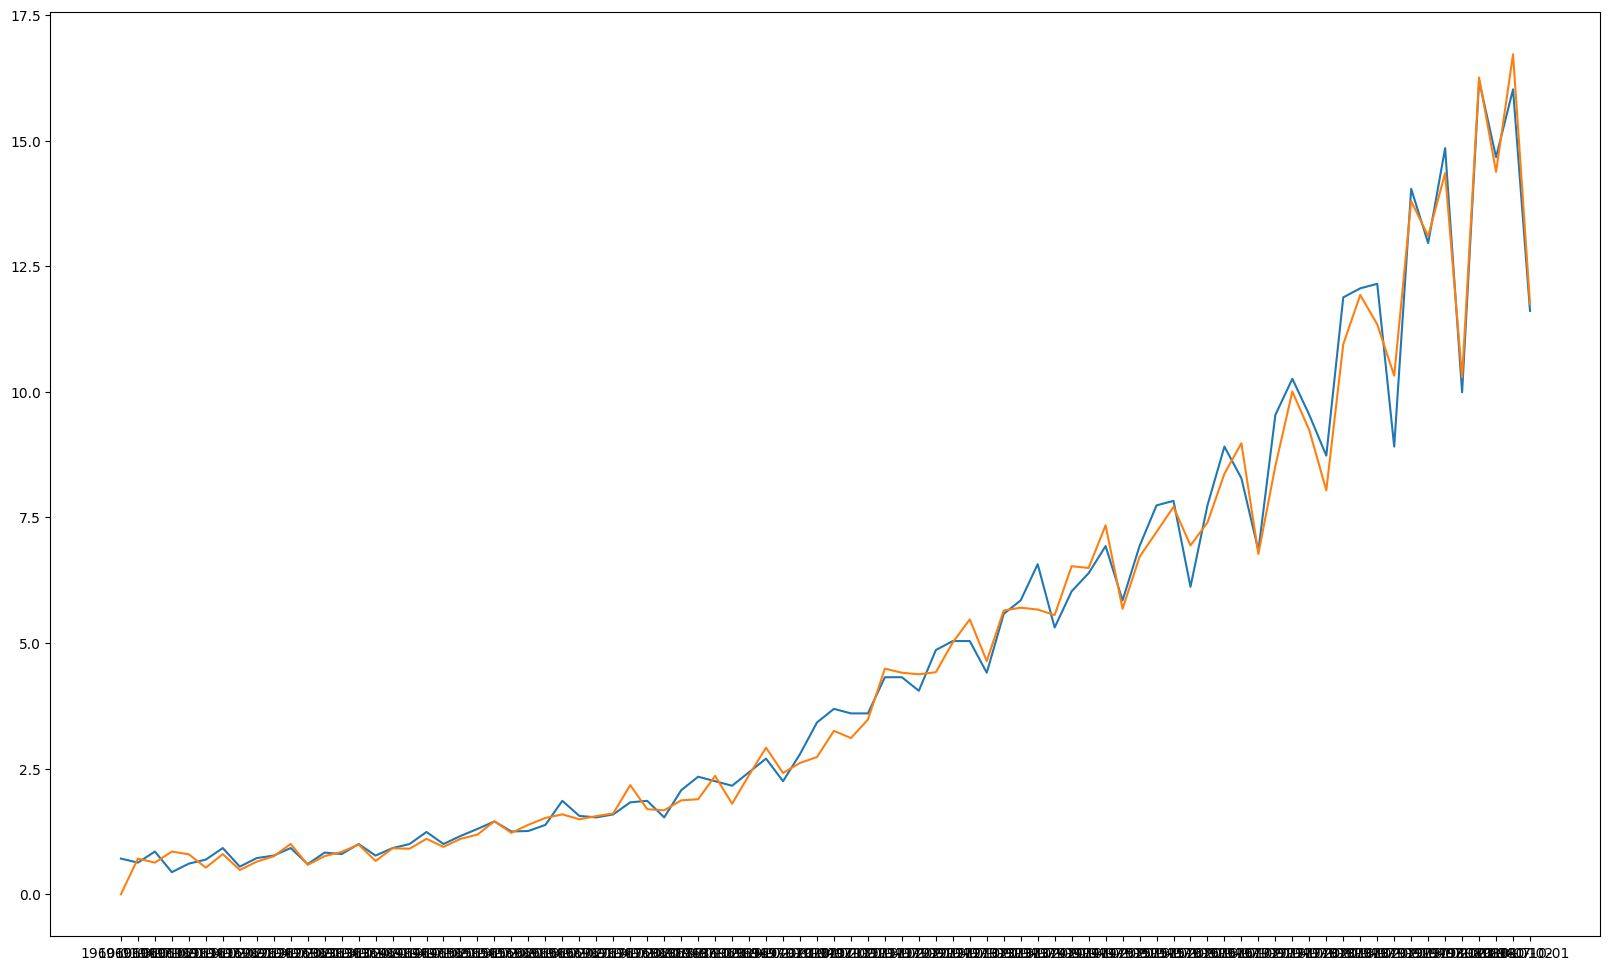

In [29]:
plt.figure(figsize=(20, 12))
plt.plot(data2['date'], data2['data'])
plt.plot(data2['date'], data2['sarimax'])
plt.show()

In [31]:
data2['sarimax'][:5] = np.nan
forecast = res.predict(start=len(data2), end=len(data2) + 8)

C:\Users\amir\AppData\Local\Temp\ipykernel_7996\2080492094.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data2['sarimax'][:5] = np.nan
C:\Users\amir\AppData\Local\Temp\ipykernel_7996\2080492094.py:1: SettingWithCopyWarning: 
A value is

In [32]:
len(data2)

84

In [34]:
forecast = pd.concat([data2['sarimax'], forecast])


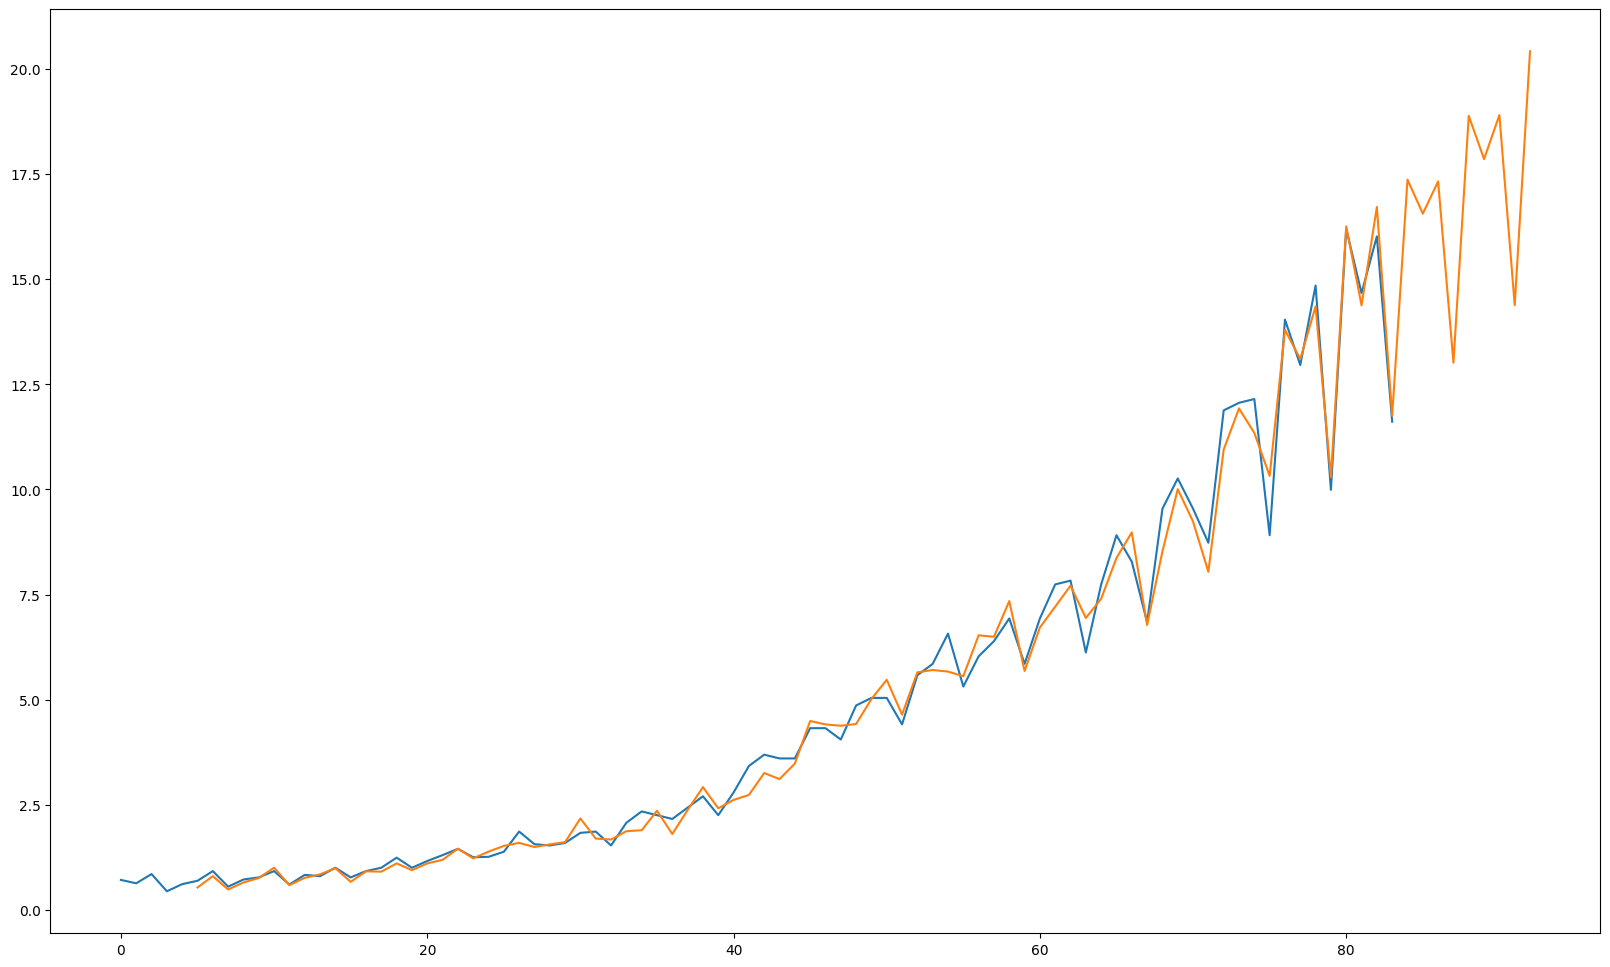

In [35]:
plt.figure(figsize=(20, 12))
plt.plot(data2['data'])
plt.plot(forecast)
plt.show()